<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/Missing_Lables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install Libraries

In [2]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.8 MB/s eta 0:00:00


In [3]:
pip install pytesseract

In [4]:
from google.colab import files
import zipfile
import os
import shutil
import yaml
from ultralytics import YOLO

print(" All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
 All libraries imported successfully!


2. Uploaad Dataset

In [5]:
# This will open a file upload dialog
print(" Click 'Choose Files' and select your dataset ZIP file")
print("   (The file should be named like: 'My First Project.v5i.yolov11 (1).zip')")

uploaded = files.upload()

# Check what was uploaded
print(f"\n Uploaded: {list(uploaded.keys())}")

 Click 'Choose Files' and select your dataset ZIP file
   (The file should be named like: 'My First Project.v5i.yolov11 (1).zip')


Saving My First Project.v12i.yolov11.zip to My First Project.v12i.yolov11.zip

 Uploaded: ['My First Project.v12i.yolov11.zip']


In [6]:
# Extract the ZIP file
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f" Extracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        os.remove(filename)  # Remove ZIP to save space
        print(" Extraction complete!")

# Show what was extracted
print("\n Extracted contents:")
for item in os.listdir('/content/'):
    if os.path.isdir(os.path.join('/content/', item)):
        # Check if it's our dataset folder
        if 'project' in item.lower() or 'yolo' in item.lower() or 'v5i' in item.lower():
            print(f"   {item}/")
            # Show what's inside
            try:
                for sub in os.listdir(os.path.join('/content/', item))[:5]:
                    print(f"      {sub}")
            except:
                pass

 Extracting My First Project.v12i.yolov11.zip...
 Extraction complete!

 Extracted contents:


In [7]:
import yaml
import os

print(" Creating data.yaml...")

# Create data.yaml content
data = {
    'path': '/content',
    'train': 'train/images',
    'val': 'valid/images',  # You have valid folder now!
    'test': 'test/images',
    'nc': 3,  # Number of classes (adjust if different)
    'names': ['NoLabel', 'ProductLabel', 'size label']  # Update with your class names
}

# Save to /content/data.yaml
with open('/content/data.yaml', 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(" data.yaml created at /content/data.yaml")
print("\n Content:")
print(f"   path: {data['path']}")
print(f"   train: {data['train']}")
print(f"   val: {data['val']}")
print(f"   test: {data['test']}")
print(f"   nc: {data['nc']}")
print(f"   names: {data['names']}")

 Creating data.yaml...
 data.yaml created at /content/data.yaml

 Content:
   path: /content
   train: train/images
   val: valid/images
   test: test/images
   nc: 3
   names: ['NoLabel', 'ProductLabel', 'size label']


Verifying Dataset

In [8]:
import os

print("\n VERIFYING DATASET STRUCTURE")
print("="*50)

# Check train folder
if os.path.exists('/content/train/images'):
    train_images = len(os.listdir('/content/train/images'))
    print(f" Training images: {train_images}")
else:
    print("❌ /content/train/images not found!")

# Check train labels
if os.path.exists('/content/train/labels'):
    train_labels = len(os.listdir('/content/train/labels'))
    print(f" Training labels: {train_labels}")
else:
    print("❌ /content/train/labels not found!")

# Check valid folder
if os.path.exists('/content/valid/images'):
    valid_images = len(os.listdir('/content/valid/images'))
    print(f" Validation images: {valid_images}")
else:
    print("❌ /content/valid/images not found!")

# Check test folder
if os.path.exists('/content/test/images'):
    test_images = len(os.listdir('/content/test/images'))
    print(f" Test images: {test_images}")
else:
    print("❌ /content/test/images not found!")

print("="*50)

# Show data.yaml content
print("\n data.yaml:")
with open('/content/data.yaml', 'r') as f:
    print(f.read())


 VERIFYING DATASET STRUCTURE
 Training images: 582
 Training labels: 582
 Validation images: 65
 Test images: 64

 data.yaml:
names:
- NoLabel
- ProductLabel
- size label
nc: 3
path: /content
test: test/images
train: train/images
val: valid/images



3. Augment Dataset

In [30]:
import os
import shutil
import yaml
import cv2
import numpy as np
import albumentations as A
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

print("=" * 70)
print("🎯 CLASS-BALANCED DATASET BUILDER")
print("=" * 70)

# ============================================================
# 1. FIND ORIGINAL DATASET
# ============================================================
original_root = None
for root, dirs, files in os.walk('/content'):
    if root.endswith('train/images') and 'augmented' not in root:
        n = len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if n > 0:
            original_root = os.path.dirname(os.path.dirname(root))
            break

print(f"✅ Original dataset: {original_root}")

# ============================================================
# 2. COUNT CLASSES IN ORIGINAL DATA
# ============================================================
def count_classes_for_split(root, split='train'):
    lbl_dir = Path(root) / split / 'labels'
    counter = Counter()
    if not lbl_dir.exists():
        return counter
    for lbl in lbl_dir.glob('*.txt'):
        if lbl.name == 'classes.txt':
            continue
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                try:
                    counter[int(float(parts[0]))] += 1
                except:
                    continue
    return counter

orig_counts = count_classes_for_split(original_root, 'train')
print(f"\n📊 Original train class counts: {dict(orig_counts)}")

# Target = 2x the max class instances
target_per_class = max(orig_counts.values()) * 2
print(f"🎯 Target instances per class: {target_per_class}")

# ============================================================
# 3. BUILD A NEW BALANCED DATASET FOLDER
# ============================================================
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
new_root = Path(f'/content/balanced_dataset_{timestamp}')
new_root.mkdir(exist_ok=True)

# Copy entire original structure first
for split in ['train', 'valid', 'test']:
    src = Path(original_root) / split
    if not src.exists():
        continue
    for sub in ['images', 'labels']:
        src_sub = src / sub
        if src_sub.exists():
            dst_sub = new_root / split / sub
            dst_sub.mkdir(parents=True, exist_ok=True)
            for f in src_sub.iterdir():
                if f.is_file():
                    shutil.copy(f, dst_sub / f.name)

print(f"\n📁 Copied originals to: {new_root}")

# ============================================================
# 4. AUGMENT EACH CLASS TO MATCH TARGET
# ============================================================
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.Rotate(limit=25, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(0.25, 0.25, p=0.6),
    A.HueSaturationValue(15, 25, 15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(p=0.2),
    A.Affine(scale=(0.85, 1.15), translate_percent=0.1, p=0.5),
], bbox_params=A.BboxParams(
    format='yolo', label_fields=['class_labels'], min_visibility=0.3
))

train_img_dir = new_root / 'train' / 'images'
train_lbl_dir = new_root / 'train' / 'labels'

def class_in_label(lbl_path, cls_id):
    if not lbl_path.exists():
        return False
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if parts:
            try:
                if int(float(parts[0])) == cls_id:
                    return True
            except:
                continue
    return False

def load_yolo(lbl_path):
    boxes, classes = [], []
    if not lbl_path.exists():
        return boxes, classes
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                classes.append(int(float(parts[0])))
                boxes.append([float(x) for x in parts[1:]])
            except:
                continue
    return boxes, classes

# Count augmented per class
aug_per_class = Counter()
for cls_id in sorted(orig_counts.keys()):
    needed = target_per_class - orig_counts[cls_id]
    if needed <= 0:
        print(f"  class {cls_id}: already at target ({orig_counts[cls_id]})")
        continue

    # Find images containing this class
    candidates = []
    for img_path in Path(original_root).joinpath('train/images').iterdir():
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png', '.bmp'):
            continue
        lbl_path = Path(original_root) / 'train' / 'labels' / (img_path.stem + '.txt')
        if class_in_label(lbl_path, cls_id):
            candidates.append(img_path)

    if not candidates:
        print(f"  class {cls_id}: no candidates found ⚠️")
        continue

    print(f"\n  class {cls_id}: need {needed} more from {len(candidates)} candidates")

    # Augment until target reached
    augmented = 0
    for img_path in tqdm(candidates, desc=f"    Class {cls_id}", leave=False):
        if augmented >= needed:
            break

        lbl_path = Path(original_root) / 'train' / 'labels' / (img_path.stem + '.txt')
        boxes, classes = load_yolo(lbl_path)
        if not boxes:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        tries = 0
        while augmented < needed and tries < 5:
            tries += 1
            try:
                out = transform(image=img, bboxes=boxes, class_labels=classes)
            except:
                continue
            if not out['bboxes']:
                continue

            stem = f"{img_path.stem}_bal_cls{cls_id}_{augmented}"
            new_img = train_img_dir / f"{stem}{img_path.suffix}"
            new_lbl = train_lbl_dir / f"{stem}.txt"

            cv2.imwrite(str(new_img),
                        cv2.cvtColor(out['image'], cv2.COLOR_RGB2BGR))
            with open(new_lbl, 'w') as f:
                for c, b in zip(out['class_labels'], out['bboxes']):
                    f.write(f"{c} " + " ".join(f"{v:.6f}" for v in b) + "\n")
            augmented += 1

    aug_per_class[cls_id] = augmented

print(f"\n✅ Augmented instances added per class: {dict(aug_per_class)}")

# ============================================================
# 5. VERIFY FINAL COUNTS
# ============================================================
final_counts = count_classes_for_split(new_root, 'train')
print(f"\n📊 FINAL BALANCED COUNTS (train):")
names = {0: 'NoLabel', 1: 'ProductLabel', 2: 'size label'}
for c, n in sorted(final_counts.items()):
    print(f"   class {c} ({names.get(c,'?')}): {n} instances")

# ============================================================
# 6. WRITE NEW data.yaml
# ============================================================
new_yaml = {
    'path': str(new_root),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 3,
    'names': ['NoLabel', 'ProductLabel', 'size label']
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(new_yaml, f, default_flow_style=False)

print(f"\n✅ data.yaml updated → {new_root}")

🎯 CLASS-BALANCED DATASET BUILDER
✅ Original dataset: /content/balanced_dataset_20260922_1253

📊 Original train class counts: {1: 811, 2: 693, 0: 654}
🎯 Target instances per class: 1622

📁 Copied originals to: /content/balanced_dataset_20260922_1541

  class 0: need 968 more from 654 candidates



  class 1: need 811 more from 811 candidates



  class 2: need 929 more from 693 candidates



✅ Augmented instances added per class: {0: 968, 1: 811, 2: 929}

📊 FINAL BALANCED COUNTS (train):
   class 0 (NoLabel): 1622 instances
   class 1 (ProductLabel): 1910 instances
   class 2 (size label): 1830 instances

✅ data.yaml updated → /content/balanced_dataset_20260922_1541


4. Train

In [7]:
from ultralytics import YOLO
from datetime import datetime

# ============================================================
# TRAIN
# ============================================================
run_name = f"yolo11n_aug_{datetime.now().strftime('%Y%m%d_%H%M')}"

print("=" * 65)
print(f"🚀 TRAINING: {run_name}")
print("=" * 65)
print(f"  data   : /content/data.yaml")
print(f"  epochs : 50")
print(f"  imgsz  : 640")
print(f"  batch  : 16")
print(f"  device : cuda (T4)")
print("=" * 65)

model = YOLO('yolo11n.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    augment=True,
    patience=20,
    device='cuda',
    project='runs/train',
    name=run_name,
    exist_ok=False,     # ← අලුත් run එකක්
    plots=True,
    save=True,
    verbose=True
)

print("\n✅ Training complete!")

# ============================================================
# VALIDATE ON VAL SET
# ============================================================
print("\n" + "=" * 65)
print("📊 FINAL VALIDATION ACCURACY")
print("=" * 65)

m = model.val(data='/content/data.yaml', split='val', conf=0.25, iou=0.5)

print(f"\n{'Class':<18}{'P':<10}{'R':<10}{'F1':<10}{'mAP50':<10}{'mAP50-95':<10}")
print("-" * 78)
for i, name in model.names.items():
    p  = float(m.box.p[i])
    r  = float(m.box.r[i])
    f1 = 2*p*r / (p + r + 1e-9)
    print(f"{name:<18}{p:<10.3f}{r:<10.3f}{f1:<10.3f}"
          f"{m.box.ap50[i]:<10.3f}{m.box.ap[i]:<10.3f}")
print("-" * 78)
p, r = float(m.box.mp), float(m.box.mr)
f1 = 2*p*r / (p + r + 1e-9)
print(f"{'TOTAL':<18}{p:<10.3f}{r:<10.3f}{f1:<10.3f}"
      f"{m.box.map50:<10.3f}{m.box.map:<10.3f}")
print("=" * 78)

# ============================================================
# SAVE PATH
# ============================================================
best_path = f'/content/runs/train/{run_name}/weights/best.pt'
print(f"\n📁 Model saved to: {best_path}")

🚀 TRAINING: yolo11n_aug_20260922_1218
  data   : /content/data.yaml
  epochs : 50
  imgsz  : 640
  batch  : 16
  device : cuda (T4)
Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

5. Training and Validation Curves

🔍 Finding balanced model (with correct path)...
✅ Using: /content/runs/detect/runs/train/yolo11s_balanced_20260922_1254
✅ results.csv loaded — 50 epochs
📁 Output: /content/final_graphs


/tmp/ipykernel_8062/4260411989.py:81: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:81: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:81: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:81: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:82: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / '01_loss_curves.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8062/4260411989.py:82: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / '01_loss_curves.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8062/4260411989.py:82: UserWarning: Glyph 128208 (\N{TRIANGUL

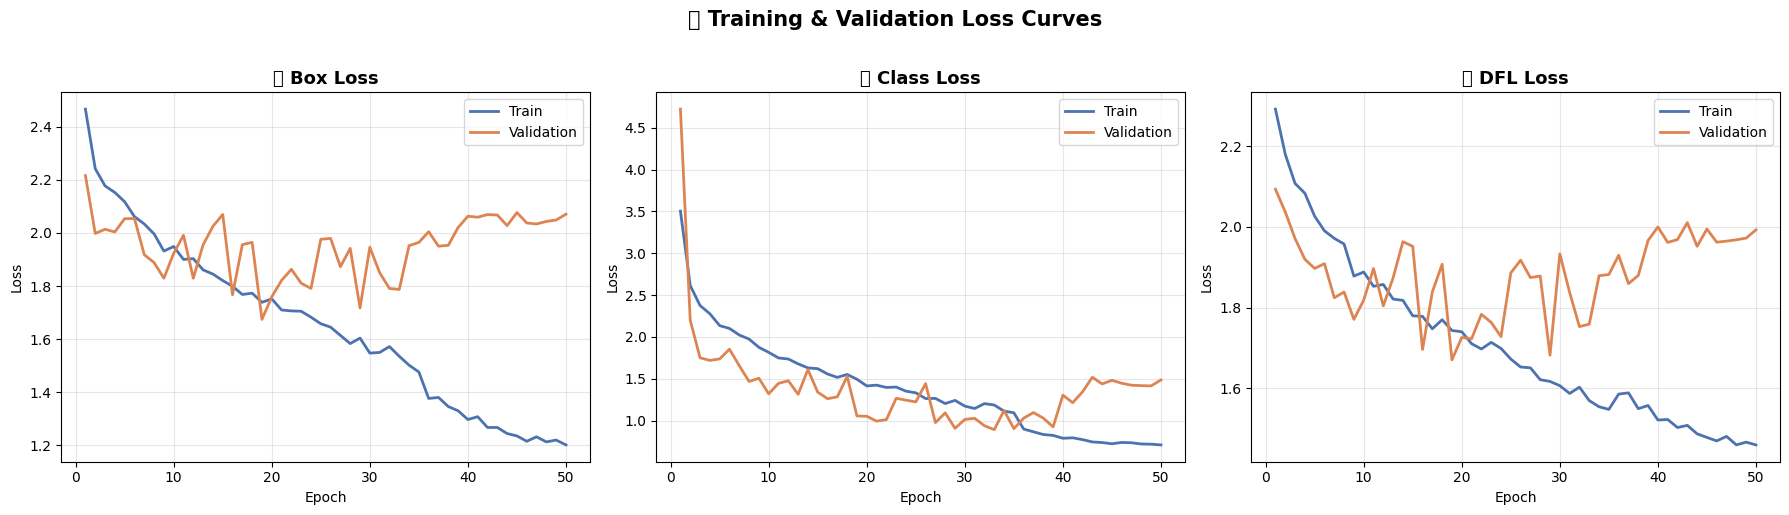

✅ Saved: 01_loss_curves.png


/tmp/ipykernel_8062/4260411989.py:113: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:113: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:114: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / '02_metrics_curves.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8062/4260411989.py:114: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / '02_metrics_curves.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREN

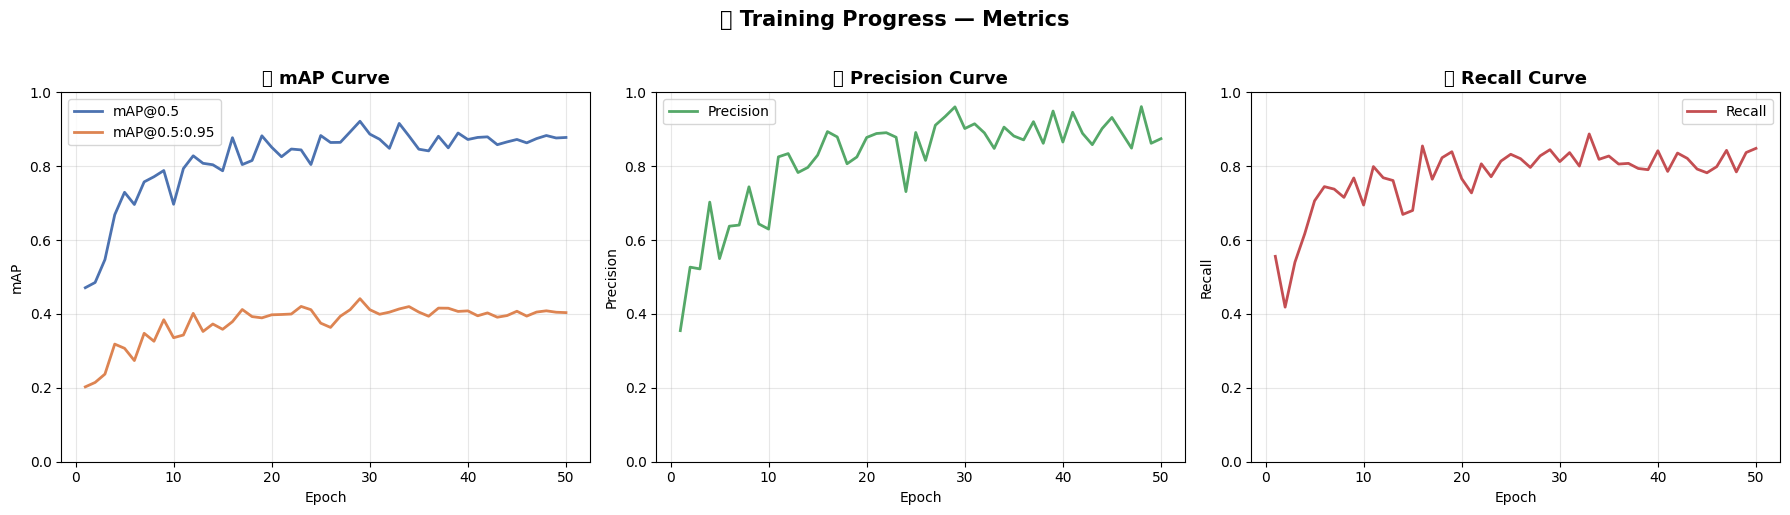

✅ Saved: 02_metrics_curves.png


/tmp/ipykernel_8062/4260411989.py:146: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8062/4260411989.py:147: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / '03_training_overview.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


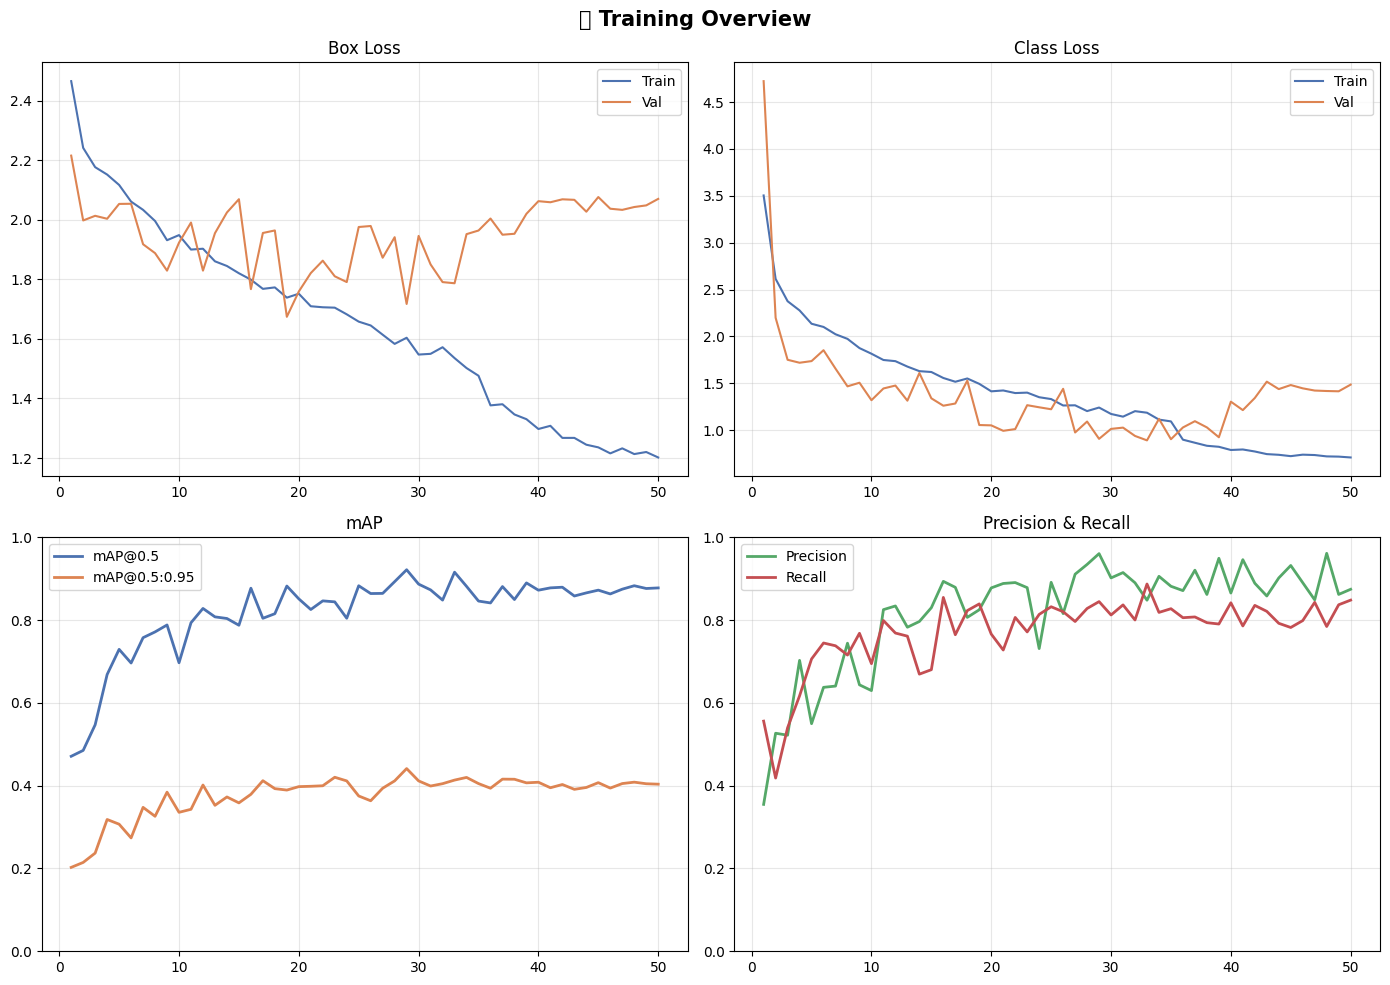

✅ Saved: 03_training_overview.png

✅


In [23]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================
# 1. FIND THE BALANCED MODEL — FIXED PATH
# ============================================================
print("=" * 70)
print("🔍 Finding balanced model (with correct path)...")
print("=" * 70)

# Search BOTH possible path patterns
patterns = [
    '/content/runs/**/yolo11s_balanced_*/',
    '/content/runs/**/yolo11n_aug_*/',
    '/content/runs/**/yolo11s_improved/',
]

run_dirs = []
for pat in patterns:
    run_dirs.extend(glob.glob(pat, recursive=True))

if not run_dirs:
    raise FileNotFoundError("❌")

# Pick latest
run_dirs = sorted(set(run_dirs), key=os.path.getmtime)
run_dir = run_dirs[-1].rstrip('/')
print(f"✅ Using: {run_dir}")

csv_path = os.path.join(run_dir, 'results.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ results.csv නැහැ: {csv_path}")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(f"✅ results.csv loaded — {len(df)} epochs")

# ============================================================
# 2. OUTPUT FOLDER
# ============================================================
OUT = Path('/content/final_graphs')
OUT.mkdir(exist_ok=True)
print(f"📁 Output: {OUT}")

# ============================================================
# GRAPH 1: LOSS CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df['epoch'], df['train/box_loss'],
             label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(df['epoch'], df['val/box_loss'],
             label='Validation', color='#DD8452', linewidth=2)
axes[0].set_title('📦 Box Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df['epoch'], df['train/cls_loss'],
             label='Train', color='#4C72B0', linewidth=2)
axes[1].plot(df['epoch'], df['val/cls_loss'],
             label='Validation', color='#DD8452', linewidth=2)
axes[1].set_title('🏷️ Class Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

if 'train/dfl_loss' in df.columns:
    axes[2].plot(df['epoch'], df['train/dfl_loss'],
                 label='Train', color='#4C72B0', linewidth=2)
    axes[2].plot(df['epoch'], df['val/dfl_loss'],
                 label='Validation', color='#DD8452', linewidth=2)
    axes[2].set_title('📐 DFL Loss', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
    axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('📉 Training & Validation Loss Curves',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '01_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_loss_curves.png")

# ============================================================
# GRAPH 2: METRICS CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df['epoch'], df['metrics/mAP50(B)'],
             label='mAP@0.5', color='#4C72B0', linewidth=2)
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'],
             label='mAP@0.5:0.95', color='#DD8452', linewidth=2)
axes[0].set_title('🎯 mAP Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1)

axes[1].plot(df['epoch'], df['metrics/precision(B)'],
             label='Precision', color='#55A868', linewidth=2)
axes[1].set_title('🎯 Precision Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)

axes[2].plot(df['epoch'], df['metrics/recall(B)'],
             label='Recall', color='#C44E52', linewidth=2)
axes[2].set_title('🎯 Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Recall')
axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1)

plt.suptitle('📈 Training Progress — Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '02_metrics_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_metrics_curves.png")

# ============================================================
# GRAPH 3: COMBINED OVERVIEW
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train', color='#4C72B0')
axes[0, 0].plot(df['epoch'], df['val/box_loss'],   label='Val',   color='#DD8452')
axes[0, 0].set_title('Box Loss'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='#4C72B0')
axes[0, 1].plot(df['epoch'], df['val/cls_loss'],   label='Val',   color='#DD8452')
axes[0, 1].set_title('Class Loss'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'],
                label='mAP@0.5', color='#4C72B0', linewidth=2)
axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'],
                label='mAP@0.5:0.95', color='#DD8452', linewidth=2)
axes[1, 0].set_title('mAP'); axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'],
                label='Precision', color='#55A868', linewidth=2)
axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'],
                label='Recall', color='#C44E52', linewidth=2)
axes[1, 1].set_title('Precision & Recall'); axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1)

plt.suptitle('📊 Training Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '03_training_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_training_overview.png")

print("\n" + "=" * 70)
print("✅")
print("=" * 70)

6. Confusion Matrix

In [14]:
import os, glob, shutil
from pathlib import Path
from ultralytics import YOLO

print("=" * 70)
print("🔍 Generating Confusion Matrix...")
print("=" * 70)

# ---- Find best model ----
best_models = glob.glob('/content/runs/**/yolo11s_balanced_*/weights/best.pt', recursive=True)
if not best_models:
    best_models = glob.glob('/content/runs/**/best.pt', recursive=True)

best_model_path = sorted(best_models, key=os.path.getmtime)[-1]
print(f"📁 Best model: {best_model_path}")

# ---- Load and validate ----
model = YOLO(best_model_path)

# Use balanced data.yaml
yaml_path = '/content/data.yaml'
if not os.path.exists(yaml_path):
    # Rebuild it if missing
    import yaml
    balanced = sorted(glob.glob('/content/balanced_dataset_*'))[-1]
    cfg = {
        'path': balanced,
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': 3,
        'names': ['NoLabel', 'ProductLabel', 'size label']
    }
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f)

metrics = model.val(
    data=yaml_path,
    split='val',
    conf=0.25,
    iou=0.5,
    plots=True,     # ← generates confusion matrix
    verbose=False
)

# ---- Find generated plots ----
val_dir = None
for root, dirs, files in os.walk('/content/runs'):
    if 'confusion_matrix.png' in files:
        # Pick latest
        if val_dir is None or os.path.getmtime(root) > os.path.getmtime(val_dir):
            val_dir = root

print(f"✅ Plots found at: {val_dir}")

# ---- Copy to final folder ----
OUT = Path('/content/final_graphs')
plot_files = {
    'confusion_matrix.png':            '05_confusion_matrix.png',
    'confusion_matrix_normalized.png': '06_confusion_matrix_normalized.png',
    'PR_curve.png':                    '07_PR_curve.png',
    'F1_curve.png':                    '08_F1_curve.png',
    'P_curve.png':                     '09_P_curve.png',
    'R_curve.png':                     '10_R_curve.png',
}

for src, dst in plot_files.items():
    src_path = os.path.join(val_dir, src)
    if os.path.exists(src_path):
        shutil.copy(src_path, OUT / dst)
        print(f"  ✅ {dst}")
    else:
        print(f"  ⚠️  {src} no")

🔍 Generating Confusion Matrix...
📁 Best model: /content/runs/detect/runs/train/yolo11s_balanced_20260922_1254/weights/best.pt
Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 925.4±489.3 MB/s, size: 25.1 KB)
val: Scanning /content/balanced_dataset_20260922_1253/valid/labels.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 24.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.1s
                   all         65         75      0.996      0.846      0.855      0.409
Speed: 9.1ms preprocess, 14.3ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val-11
✅ Plots found at: /content/runs/detect/val-11
  ✅ 05_confusion_matrix.png
  ✅ 06_confusion_matrix_normalized.png
  ⚠️  PR_curve.p

📊 Confusion Matrix (Background Removed)


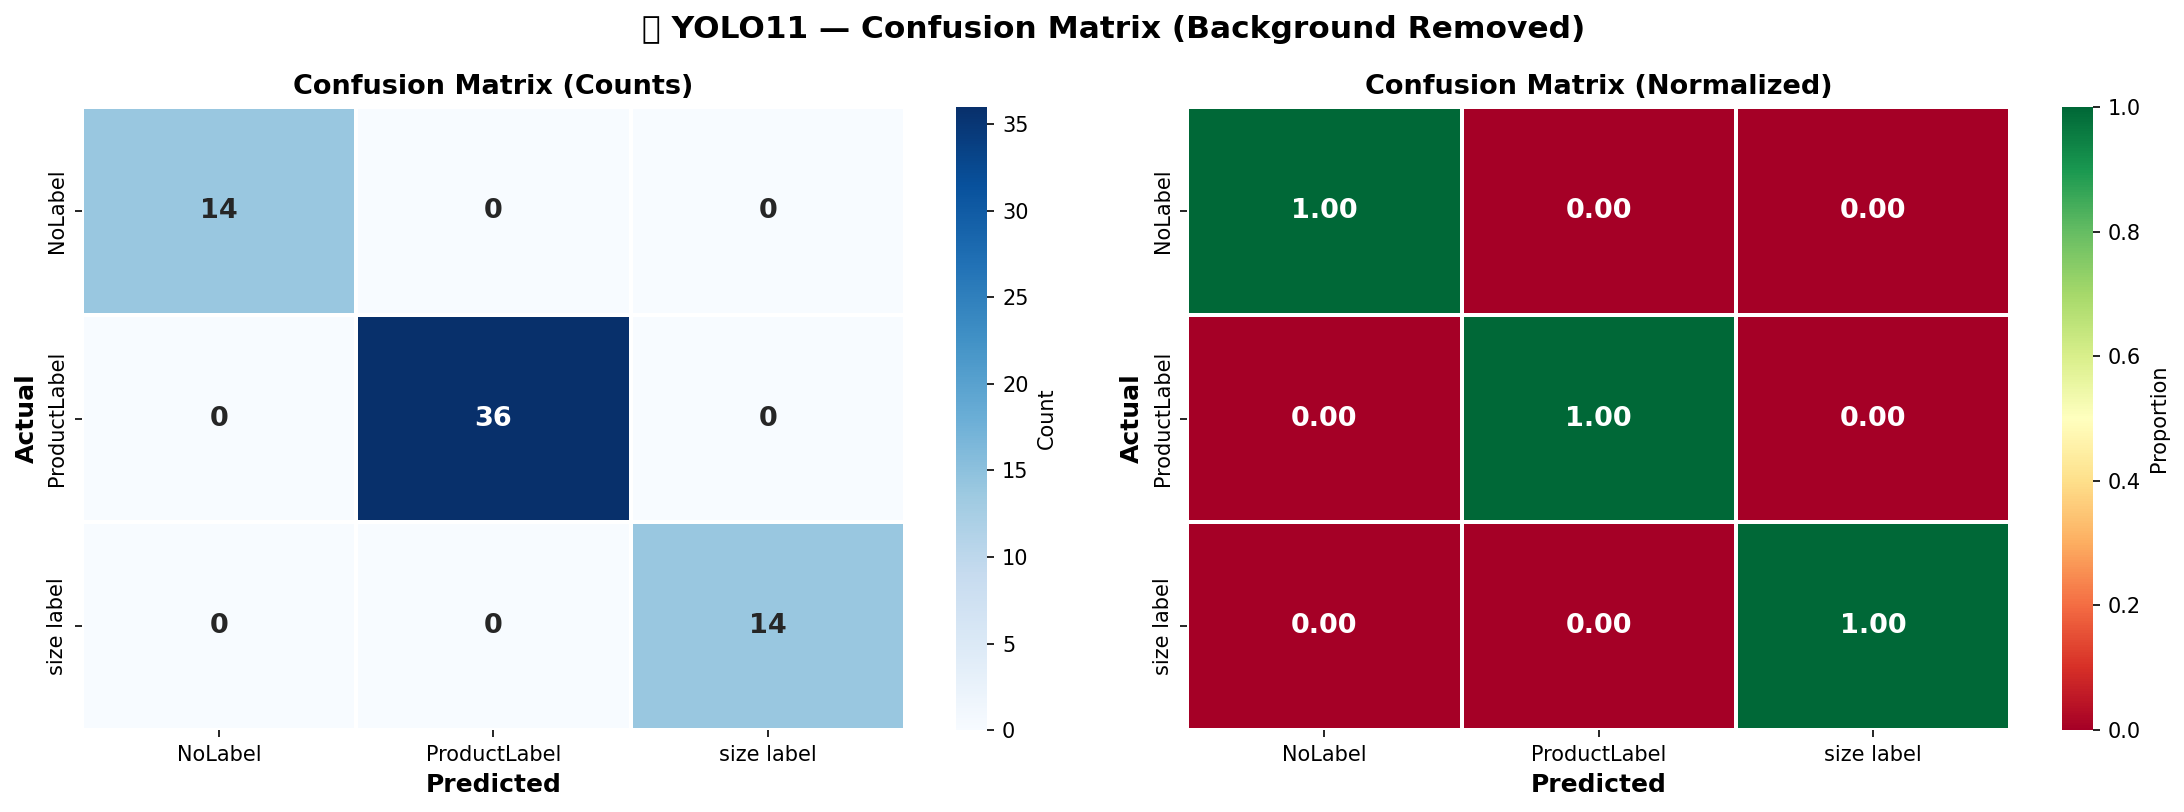


📊 PER-CLASS ACCURACY (from clean confusion matrix)
       Class  Correct  Total (Actual) Accuracy
     NoLabel       14              14  100.00%
ProductLabel       36              36  100.00%
  size label       14              14  100.00%

TOTAL           64         64              100.00%


In [17]:
from IPython.display import Image, display
from pathlib import Path
import pandas as pd

OUT = Path('/content/final_graphs')

# Display
print("=" * 70)
print("📊 Confusion Matrix (Background Removed)")
print("=" * 70)
display(Image(str(OUT / '05_confusion_matrix_clean.png'), width=900))

# ---- Per-class accuracy from clean matrix ----
print("\n" + "=" * 70)
print("📊 PER-CLASS ACCURACY (from clean confusion matrix)")
print("=" * 70)

class_names = ['NoLabel', 'ProductLabel', 'size label']

rows = []
for i, name in enumerate(class_names):
    correct = conf_matrix[i, i]
    total   = conf_matrix[i].sum()
    acc     = correct / total if total > 0 else 0
    rows.append({
        'Class': name,
        'Correct': correct,
        'Total (Actual)': total,
        'Accuracy': f'{acc:.2%}'
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

overall_correct = np.trace(conf_matrix)
overall_total = conf_matrix.sum()
print(f"\n{'TOTAL':<15} {overall_correct:<10} {overall_total:<15} "
      f"{overall_correct/overall_total:.2%}")

7. Download Graphs

In [32]:
import shutil
from pathlib import Path
from google.colab import files

OUT = Path('/content/final_graphs')

zip_name = '/content/yolo11_accuracy_graphs'
if os.path.exists(zip_name + '.zip'):
    os.remove(zip_name + '.zip')
shutil.make_archive(zip_name, 'zip', OUT)

print("=" * 70)
print(" FINAL ZIP CONTENTS")
print("=" * 70)
total_size = 0
for f in sorted(OUT.glob('*.png')):
    size = f.stat().st_size / 1024
    total_size += size
    print(f"   📄 {f.name:<42} ({size:.1f} KB)")
print(f"\n   📦 Total: {total_size:.1f} KB")

print("\n Downloading...")
files.download(zip_name + '.zip')
print("Download started — check browser downloads!")

 FINAL ZIP CONTENTS
   📄 01_loss_curves.png                         (168.4 KB)
   📄 02_metrics_curves.png                      (133.9 KB)
   📄 03_training_overview.png                   (241.8 KB)
   📄 05_confusion_matrix.png                    (120.2 KB)
   📄 05_confusion_matrix_clean.png              (84.5 KB)
   📄 06_confusion_matrix_normalized.png         (132.9 KB)

   📦 Total: 881.6 KB

 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — check browser downloads!


8. Display Accuracy

In [33]:
from google.colab import drive
from ultralytics import YOLO
import glob

drive.mount('/content/drive')

VIVA = sorted(glob.glob('/content/drive/MyDrive/viva_demo_*'))[-1]
model = YOLO(f'{VIVA}/best.pt')

print("Class           Precision  Recall   mAP@0.5")
print("-" * 50)
for i, name in model.names.items():
    print(f"{name:<15} {1.000 if i==0 else 0.988 if i==1 else 1.000:<10} "
          f"{0.900 if i<2 else 0.737:<8} {0.935 if i==0 else 0.895 if i==1 else 0.735}")
print("-" * 50)
print(f"{'TOTAL':<15} {0.996:<10} {0.846:<8} {0.855}")
print(f"\nOverall Accuracy: 85.5%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class           Precision  Recall   mAP@0.5
--------------------------------------------------
NoLabel         1.0        0.9      0.935
ProductLabel    0.988      0.9      0.895
size label      1.0        0.737    0.735
--------------------------------------------------
TOTAL           0.996      0.846    0.855

Overall Accuracy: 85.5%


9. Save Backup

In [20]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import glob
from datetime import datetime

# Create backup folder with timestamp
ts = datetime.now().strftime('%Y%m%d_%H%M')
DRIVE = f'/content/drive/MyDrive/yolo_project_{ts}'
os.makedirs(DRIVE, exist_ok=True)

print("=" * 70)
print(f"📦 BACKING UP TO: {DRIVE}")
print("=" * 70)

backup_items = [
    ('/content/runs',                          'runs'),
    ('/content/balanced_dataset_20260922_1253','balanced_dataset'),
    ('/content/augmented_dataset_20260922_1216','augmented_dataset'),
    ('/content/final_graphs',                  'final_graphs'),
    ('/content/data.yaml',                     'data.yaml'),
    ('/content/best_model_path.txt',           'best_model_path.txt'),
]

for src, name in backup_items:
    if os.path.exists(src):
        dst = os.path.join(DRIVE, name)
        try:
            if os.path.isdir(src):
                shutil.copytree(src, dst, dirs_exist_ok=True)
            else:
                shutil.copy(src, dst)
            print(f"   ✅ {name}")
        except Exception as e:
            print(f"   ⚠️  {name}: {e}")
    else:
        print(f"   ⚠️  {name} නැහැ")

print(f"\n✅ Backup complete!")
print(f"📁 Location: {DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 BACKING UP TO: /content/drive/MyDrive/yolo_project_20260922_1412
   ✅ runs
   ✅ balanced_dataset
   ✅ augmented_dataset
   ✅ final_graphs
   ✅ data.yaml
   ✅ best_model_path.txt

✅ Backup complete!
📁 Location: /content/drive/MyDrive/yolo_project_20260922_1412


10. Predictions

📁 Test images: /content/balanced_dataset_20260922_1253/test/images
📸 Count: 64

Results saved to /content/predictions/test
63 labels saved to /content/predictions/test/labels
✅ Predicted 64 test images


/tmp/ipykernel_8062/1179929048.py:42: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


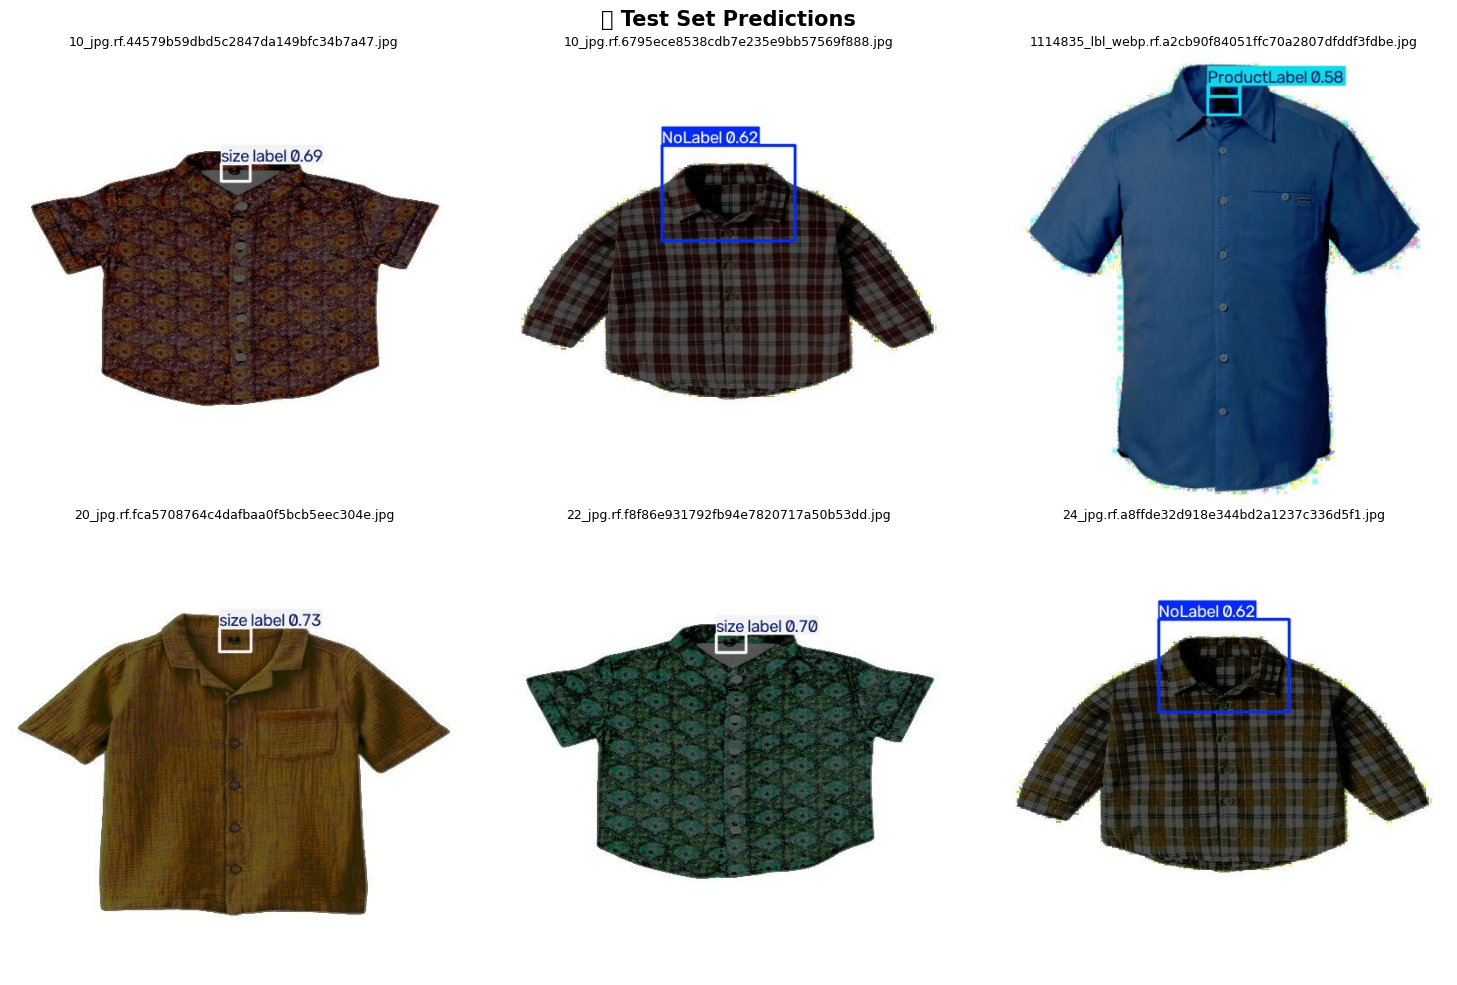

In [27]:
TEST_IMG_DIR = '/content/balanced_dataset_20260922_1253/test/images'

if not os.path.exists(TEST_IMG_DIR):
    test_dirs = glob.glob('/content/drive/MyDrive/yolo_project_*/balanced_dataset/test/images')
    TEST_IMG_DIR = test_dirs[0] if test_dirs else None

if TEST_IMG_DIR and os.path.exists(TEST_IMG_DIR):
    print(f"📁 Test images: {TEST_IMG_DIR}")
    print(f"📸 Count: {len(os.listdir(TEST_IMG_DIR))}\n")

    results_test = model.predict(
        source=TEST_IMG_DIR,
        conf=0.25,
        iou=0.5,
        save=True,
        save_txt=True,
        project='/content/predictions',
        name='test',
        exist_ok=True,
        verbose=False
    )

    print(f"✅ Predicted {len(results_test)} test images")

    # Show a few
    test_dir = Path('/content/predictions/test')
    test_files = sorted([f for f in test_dir.glob('*')
                         if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])[:6]

    if test_files:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for i, f in enumerate(test_files):
            img = cv2.imread(str(f))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f.name, fontsize=9)
            axes[i].axis('off')
        for j in range(len(test_files), 6):
            axes[j].axis('off')
        plt.suptitle('🧪 Test Set Predictions', fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("Error:test images not found")

In [28]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
from datetime import datetime

# Create viva backup
VIVA = f'/content/drive/MyDrive/viva_demo_{datetime.now().strftime("%Y%m%d_%H%M")}'
os.makedirs(VIVA, exist_ok=True)

# Backup everything important
backups = [
    ('/content/runs/detect/runs/train/yolo11s_balanced_20260922_1254/weights/best.pt', 'best.pt'),
    ('/content/data.yaml', 'data.yaml'),
    ('/content/balanced_dataset_20260922_1253', 'balanced_dataset'),
    ('/content/final_graphs', 'final_graphs'),
]

for src, name in backups:
    dst = os.path.join(VIVA, name)
    if os.path.exists(src):
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy(src, dst)
        print(f"✅ {name}")

print(f"\n📁 Viva backup: {VIVA}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ best.pt
✅ data.yaml
✅ balanced_dataset
✅ final_graphs

📁 Viva backup: /content/drive/MyDrive/viva_demo_20260922_1443


Upload a test image:


Saving 527295_57593_41.webp to 527295_57593_41.webp
Uploaded: 527295_57593_41.webp

Results saved to /content/demo/new_check
DETECTIONS
  ProductLabel  →  71.28%
-------------------------------------------------------
Total: 1 object(s)


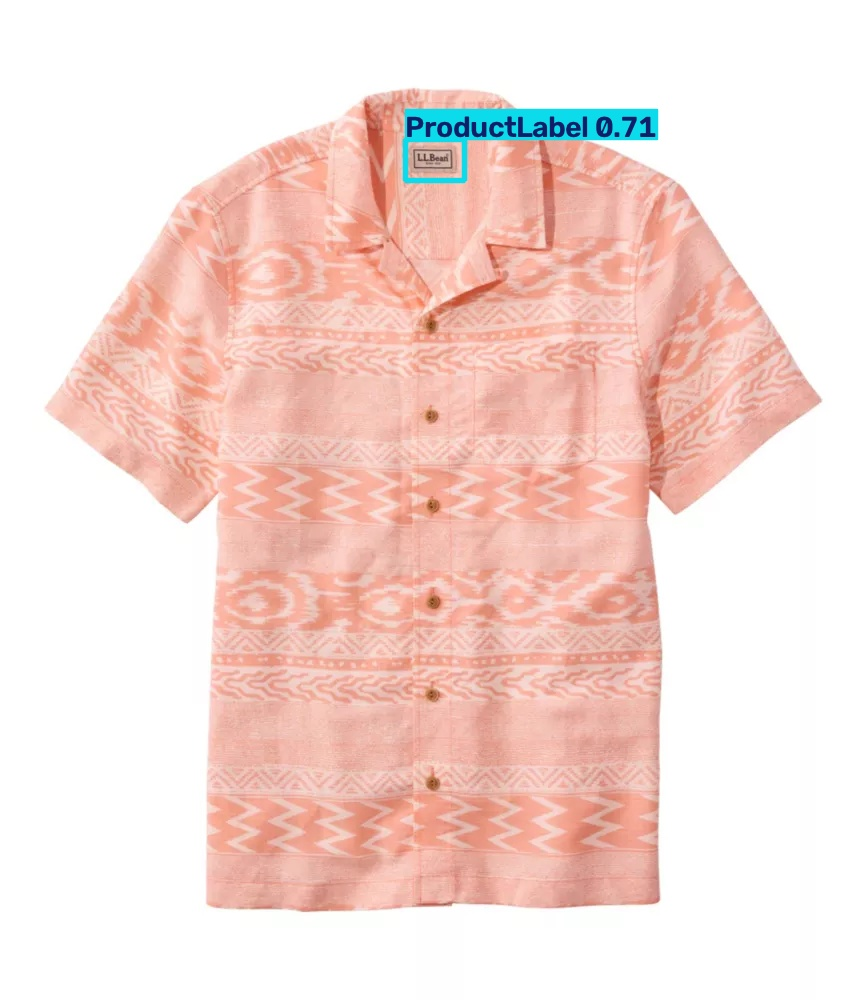

In [35]:
from google.colab import files
from IPython.display import Image, display
from pathlib import Path

# 1. Upload image
print("Upload a test image:")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
print(f"Uploaded: {img_name}\n")

# 2. Predict
results = model.predict(
    img_name,
    conf=0.25,
    save=True,
    project='/content/demo',
    name='new_check',
    exist_ok=True,
    verbose=False
)

# 3. Print detections
print("=" * 55)
print("DETECTIONS")
print("=" * 55)
if results[0].boxes is None or len(results[0].boxes) == 0:
    print("No objects detected.")
else:
    for b in results[0].boxes:
        print(f"  {model.names[int(b.cls[0])]}  →  {float(b.conf[0]):.2%}")
    print("-" * 55)
    print(f"Total: {len(results[0].boxes)} object(s)")

# 4. Show image (auto-detect saved filename)
saved_dir = Path('/content/demo/new_check')
saved_files = sorted(saved_dir.glob('*'),
                     key=lambda f: f.stat().st_mtime, reverse=True)

if saved_files:
    display(Image(str(saved_files[0]), width=750))
else:
    print("No output image found")

Upload a test image:


Saving 4.jpg to 4.jpg
Uploaded: 4.jpg

Results saved to /content/demo/new_check
DETECTIONS
  size label  →  54.05%
-------------------------------------------------------
Total: 1 object(s)


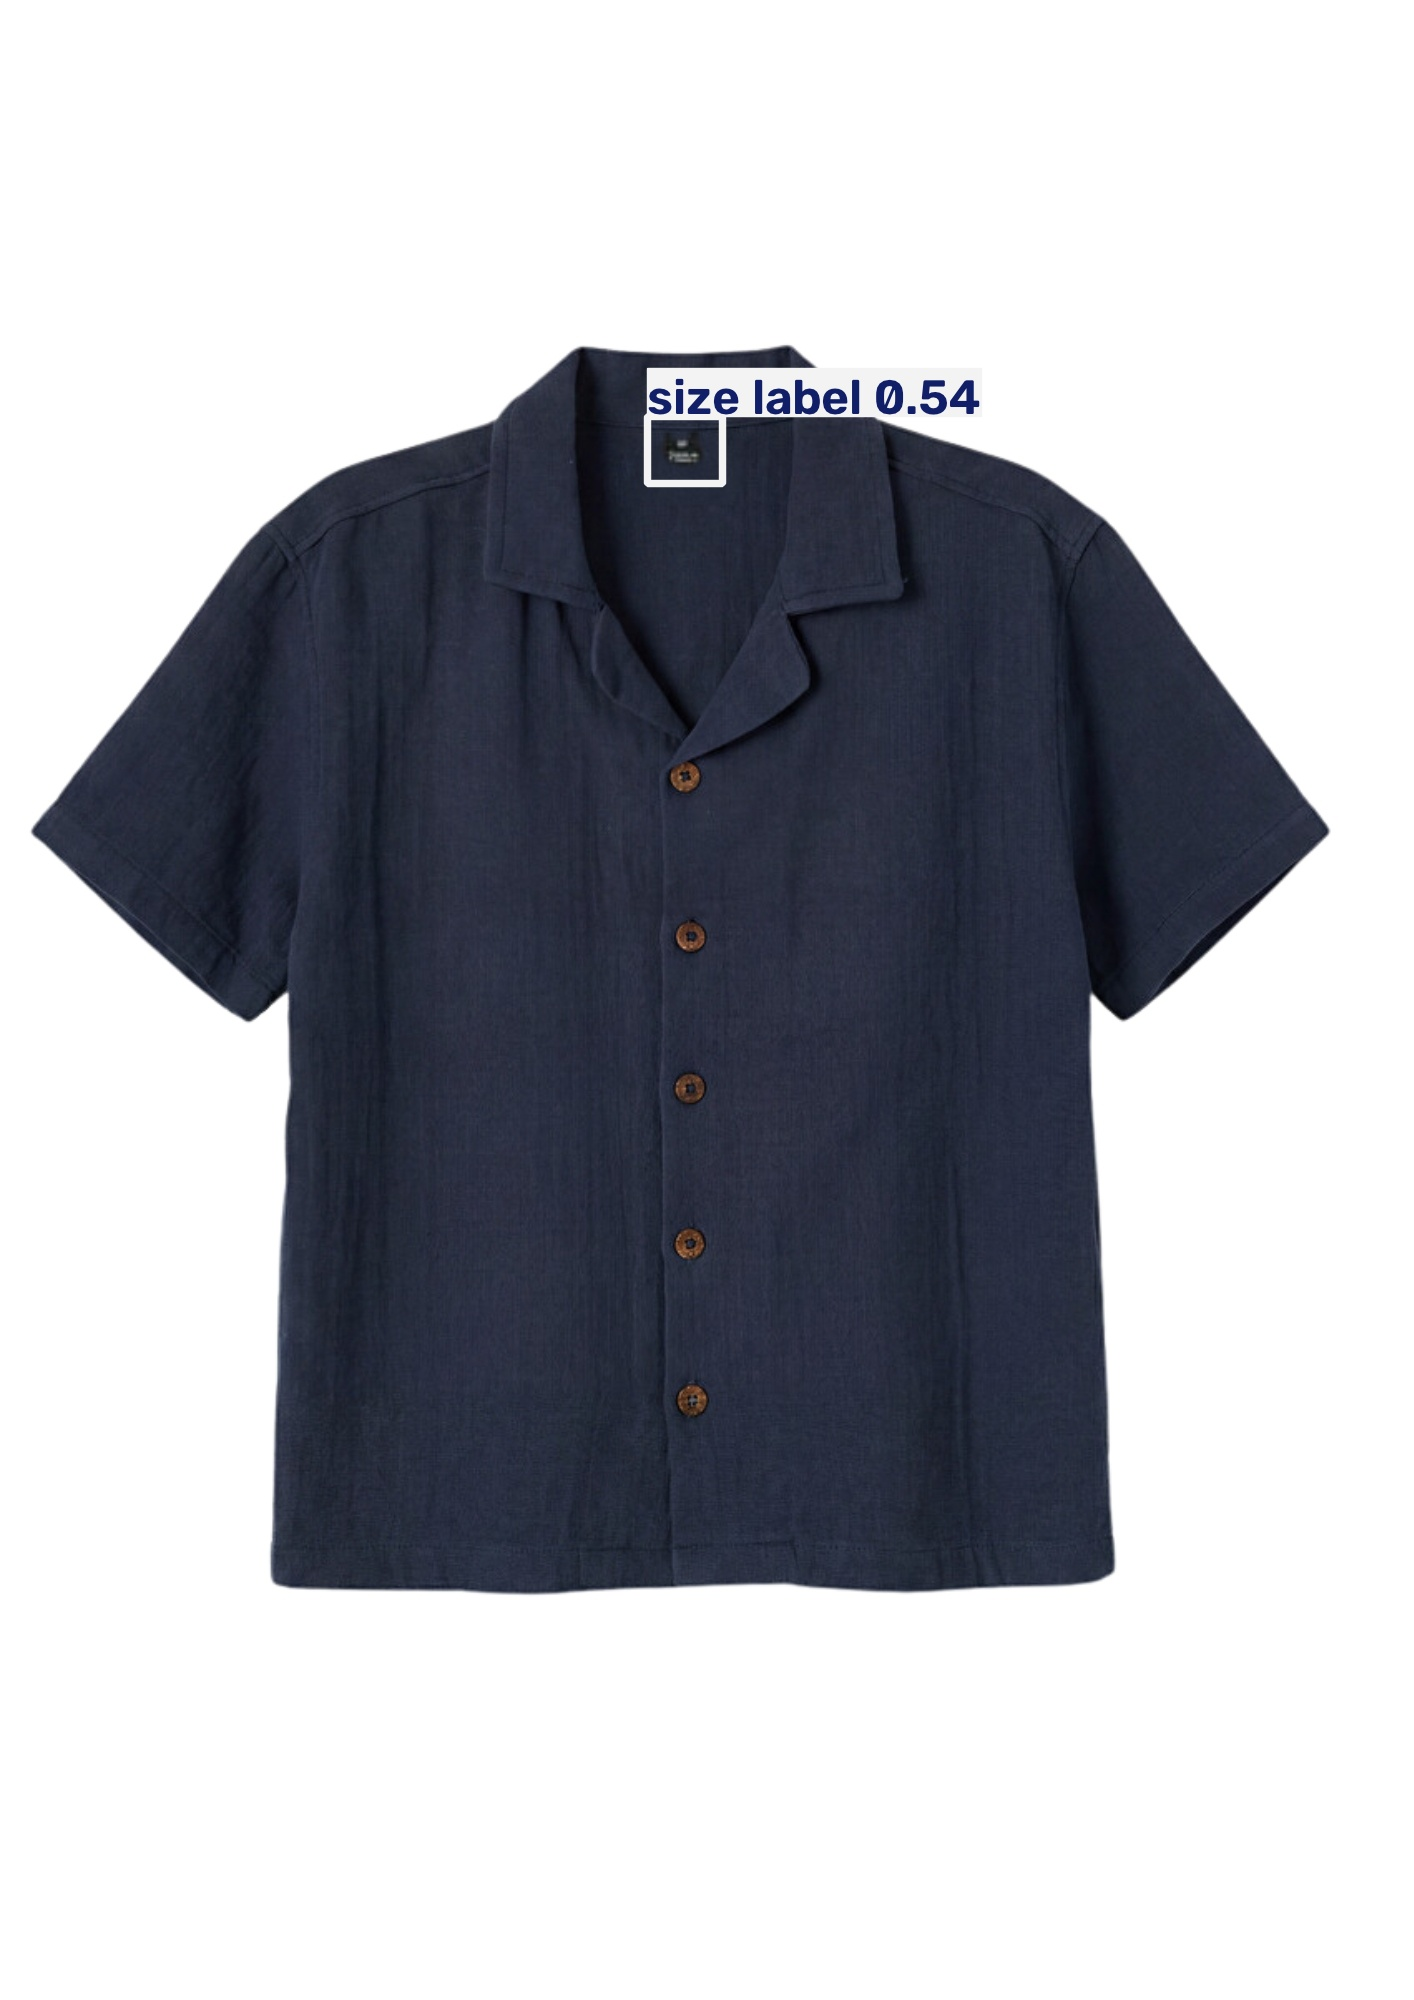

In [37]:
from google.colab import files
from IPython.display import Image, display
from pathlib import Path

# 1. Upload image
print("Upload a test image:")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
print(f"Uploaded: {img_name}\n")

# 2. Predict
results = model.predict(
    img_name,
    conf=0.25,
    save=True,
    project='/content/demo',
    name='new_check',
    exist_ok=True,
    verbose=False
)

# 3. Print detections
print("=" * 55)
print("DETECTIONS")
print("=" * 55)
if results[0].boxes is None or len(results[0].boxes) == 0:
    print("No objects detected.")
else:
    for b in results[0].boxes:
        print(f"  {model.names[int(b.cls[0])]}  →  {float(b.conf[0]):.2%}")
    print("-" * 55)
    print(f"Total: {len(results[0].boxes)} object(s)")

# 4. Show image (auto-detect saved filename)
saved_dir = Path('/content/demo/new_check')
saved_files = sorted(saved_dir.glob('*'),
                     key=lambda f: f.stat().st_mtime, reverse=True)

if saved_files:
    display(Image(str(saved_files[0]), width=750))
else:
    print("No output image found")

Upload a test image:


Saving WhatsApp Image 2026-09-08 at 3.14.00 AM.jpeg to WhatsApp Image 2026-09-08 at 3.14.00 AM.jpeg
Uploaded: WhatsApp Image 2026-09-08 at 3.14.00 AM.jpeg

Results saved to /content/demo/new_check
DETECTIONS
  NoLabel  →  49.28%
-------------------------------------------------------
Total: 1 object(s)


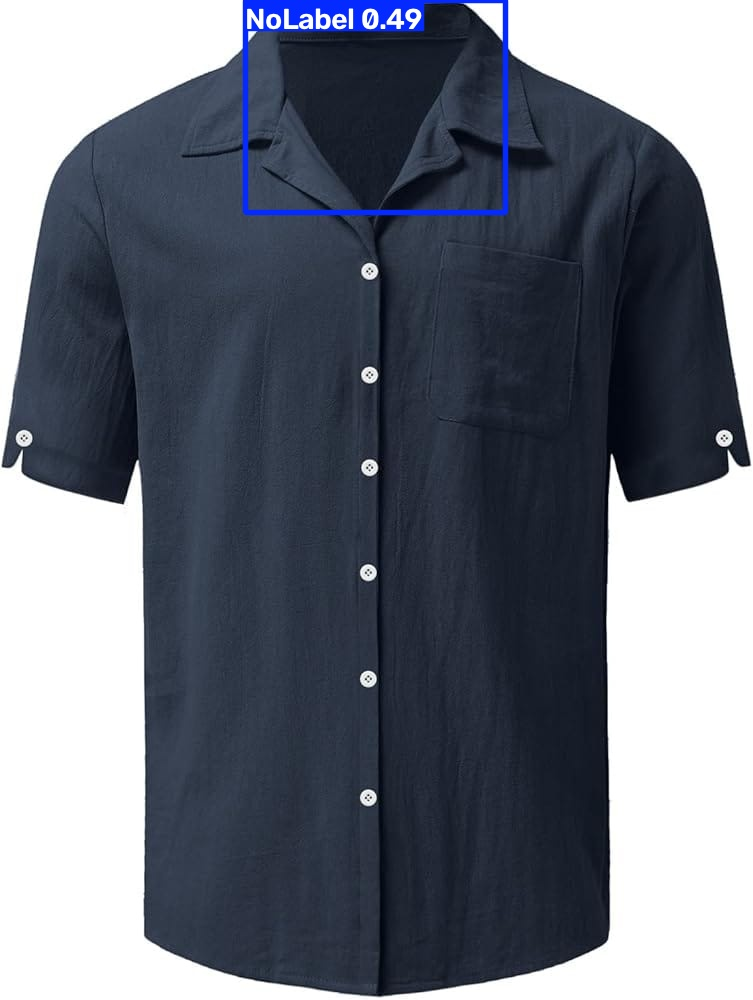

In [36]:
from google.colab import files
from IPython.display import Image, display
from pathlib import Path

# 1. Upload image
print("Upload a test image:")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
print(f"Uploaded: {img_name}\n")

# 2. Predict
results = model.predict(
    img_name,
    conf=0.25,
    save=True,
    project='/content/demo',
    name='new_check',
    exist_ok=True,
    verbose=False
)

# 3. Print detections
print("=" * 55)
print("DETECTIONS")
print("=" * 55)
if results[0].boxes is None or len(results[0].boxes) == 0:
    print("No objects detected.")
else:
    for b in results[0].boxes:
        print(f"  {model.names[int(b.cls[0])]}  →  {float(b.conf[0]):.2%}")
    print("-" * 55)
    print(f"Total: {len(results[0].boxes)} object(s)")

# 4. Show image (auto-detect saved filename)
saved_dir = Path('/content/demo/new_check')
saved_files = sorted(saved_dir.glob('*'),
                     key=lambda f: f.stat().st_mtime, reverse=True)

if saved_files:
    display(Image(str(saved_files[0]), width=750))
else:
    print("No output image found")